Afrin Munshi 24EE10030, B.Tech EE IIT Kharagpur

In [1]:
!pip install -q scikit-surprise

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, SVD, SVDpp, NMF
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy
from collections import defaultdict

In [3]:
data = Dataset.load_builtin('ml-100k')

print("MovieLens 100K loaded.")
print("100,000 ratings | 943 users | 1,682 movies")
print("Rating scale: 1 to 5")

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k
MovieLens 100K loaded.
100,000 ratings | 943 users | 1,682 movies
Rating scale: 1 to 5


            user_id        item_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08

Unique users  : 943
Unique movies : 1682
Total ratings : 100000
Mean rating   : 3.53
Sparsity      : 0.9370


/tmp/ipykernel_5011/2317112860.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='Blues_d')


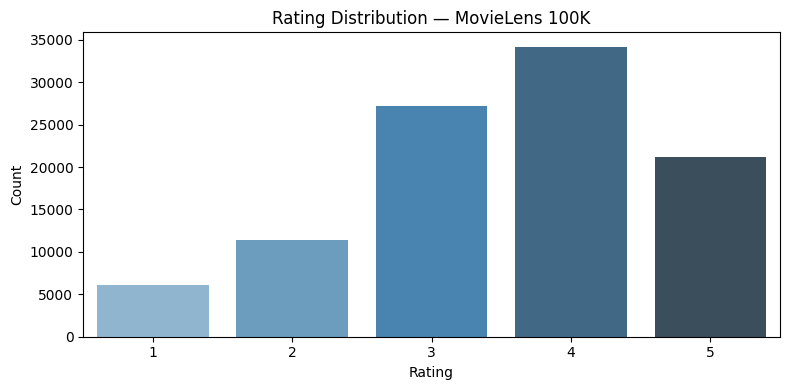

In [4]:

df = pd.read_csv('~/.surprise_data/ml-100k/ml-100k/u.data',
                 sep='\t', names=['user_id','item_id','rating','timestamp'])

print(df.describe())
print(f"\nUnique users  : {df['user_id'].nunique()}")
print(f"Unique movies : {df['item_id'].nunique()}")
print(f"Total ratings : {len(df)}")
print(f"Mean rating   : {df['rating'].mean():.2f}")
print(f"Sparsity      : {1 - len(df) / (df['user_id'].nunique() * df['item_id'].nunique()):.4f}")

plt.figure(figsize=(8,4))
sns.countplot(x='rating', data=df, palette='Blues_d')
plt.title('Rating Distribution — MovieLens 100K')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

EDA Observations:


*   The matrix is 93.7% sparse — only 6.3% of possible user-movie pairs have a rating, making this a classic cold-start problem that dense latent factor models like SVD are specifically designed to solve.
*   Ratings are negatively skewed with mean 3.53 and mode 4, the distribution is dominated by positive ratings (3–5), with ratings 1 and 2 forming a thin left tail. This reflects selection bias: users predominantly rate movies they actively chose to watch and therefore have some prior interest in, rather than random selections.







*   Rating 4 is the single most common score (34,000+ ratings), with rating 1 the rarest (6,000) — the model will see far more examples of positive sentiment than negative, which may slightly bias predicted ratings upward.




In [5]:
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

print(f"Training ratings : {trainset.n_ratings}")
print(f"Test ratings     : {len(testset)}")

Training ratings : 80000
Test ratings     : 20000


In [6]:
models = {
    'SVD'   : SVD(random_state=42),
    'NMF'   : NMF(random_state=42),
}

results = {}
for name, model in models.items():
    cv_results = cross_validate(model, data, measures=['RMSE','MAE'],
                                cv=5, verbose=False)
    results[name] = {
        'RMSE' : cv_results['test_rmse'].mean(),
        'MAE'  : cv_results['test_mae'].mean(),
        'RMSE_std' : cv_results['test_rmse'].std(),
    }
    print(f"{name:8} | RMSE: {results[name]['RMSE']:.4f} ± {results[name]['RMSE_std']:.4f} | MAE: {results[name]['MAE']:.4f}")

SVD      | RMSE: 0.9352 ± 0.0038 | MAE: 0.7370
NMF      | RMSE: 0.9665 ± 0.0064 | MAE: 0.7595


Model Comparison:

SVD outperforms NMF on both RMSE (0.9352 vs 0.9665) and MAE (0.7370 vs 0.7595) with notably lower cross-validation variance (±0.0038 vs ±0.0064), indicating more consistent generalization across folds. NMF's non-negativity constraint, while improving interpretability of latent factors, restricts the hypothesis space in a way that hurts predictive accuracy on this dataset. SVD is selected as the final model.

Why SVD?

SVD (Singular Value Decomposition) decomposes the sparse user-item matrix into two dense latent factor matrices — one for users, one for items — of dimension k. Each latent dimension captures an abstract preference axis (e.g. genre affinity, production quality preference) that is never explicitly labeled. Predicted ratings are the dot product of a user's and item's latent vectors. NMF (Non-negative Matrix Factorization) applies the same idea with a non-negativity constraint, making factors more interpretable but generally less accurate.

In [7]:
best_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005,
                 reg_all=0.02, random_state=42)
best_model.fit(trainset)

predictions = best_model.test(testset)

rmse = accuracy.rmse(predictions)
mae  = accuracy.mae(predictions)

print(f"\nTest RMSE : {rmse:.4f}")
print(f"Test MAE  : {mae:.4f}")

RMSE: 0.9352
MAE:  0.7375

Test RMSE : 0.9352
Test MAE  : 0.7375


Hyperparameter justification:


*   n_factors=100: number of latent dimensions. Higher values capture more nuanced preferences but risk overfitting on sparse data. 100 is the standard benchmark value for MovieLens 100K.
*   lr_all=0.005: learning rate for SGD optimization of latent factors. Standard range is 0.002–0.01.


*   reg_all=0.02: L2 regularization on all parameters, preventing latent vectors from overfitting to users or items with very few ratings.









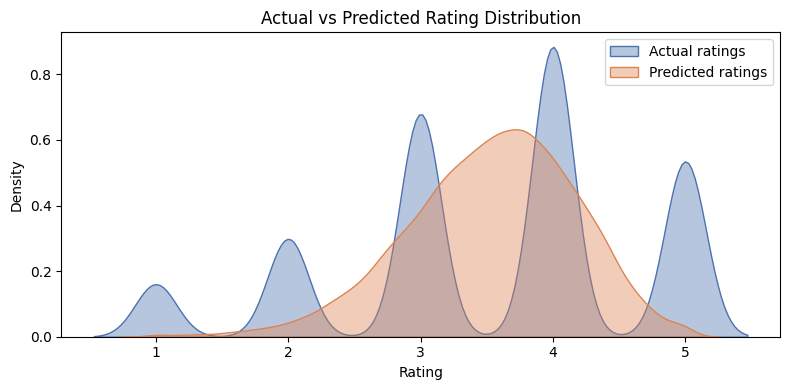

In [8]:
actual    = [pred.r_ui for pred in predictions]
predicted = [pred.est  for pred in predictions]

plt.figure(figsize=(8,4))
sns.kdeplot(actual,    label='Actual ratings',    fill=True, alpha=0.4, color='#4C72B0')
sns.kdeplot(predicted, label='Predicted ratings', fill=True, alpha=0.4, color='#DD8452')
plt.title('Actual vs Predicted Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

In [9]:
def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

top_n = get_top_n(predictions, n=10)


movies = pd.read_csv('~/.surprise_data/ml-100k/ml-100k/u.item',
                     sep='|', encoding='latin-1', header=None)
movies.columns = ['item_id','title'] + list(range(22))
movie_dict = dict(zip(movies['item_id'].astype(str), movies['title']))


sample_user = '1'
print(f"Top 10 recommendations for User {sample_user}:\n")
for i, (item_id, est_rating) in enumerate(top_n[sample_user], 1):
    title = movie_dict.get(item_id, f"Movie {item_id}")
    print(f"{i:2}. {title:<45} Predicted rating: {est_rating:.2f}")

Top 10 recommendations for User 1:

 1. Citizen Kane (1941)                           Predicted rating: 4.75
 2. Silence of the Lambs, The (1991)              Predicted rating: 4.67
 3. Kolya (1996)                                  Predicted rating: 4.51
 4. Henry V (1989)                                Predicted rating: 4.37
 5. Apocalypse Now (1979)                         Predicted rating: 4.22
 6. Indiana Jones and the Last Crusade (1989)     Predicted rating: 4.17
 7. Big Night (1996)                              Predicted rating: 4.13
 8. Dead Man Walking (1995)                       Predicted rating: 4.05
 9. Room with a View, A (1986)                    Predicted rating: 4.03
10. Gattaca (1997)                                Predicted rating: 4.02


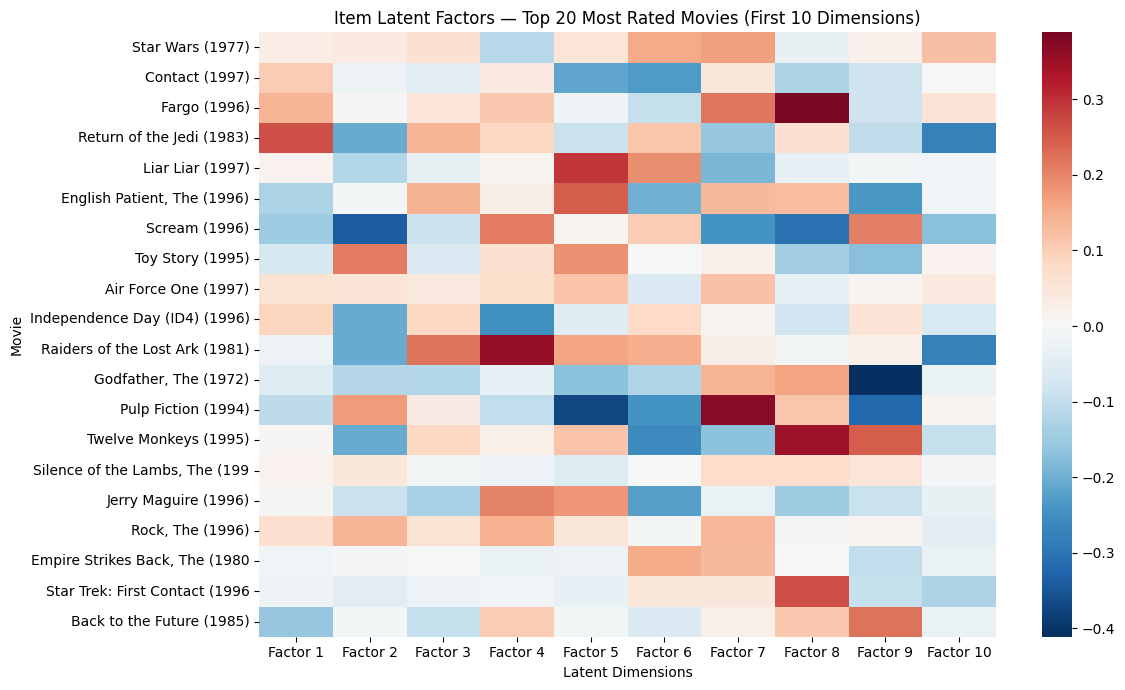

In [10]:

item_factors = best_model.qi


top_movies = df['item_id'].value_counts().head(20).index.tolist()


trainset2 = data.build_full_trainset()
inner_ids  = [trainset2.to_inner_iid(str(mid)) for mid in top_movies if str(mid) in trainset2._raw2inner_id_items]
titles     = [movie_dict.get(str(mid), str(mid))[:30] for mid in top_movies if str(mid) in trainset2._raw2inner_id_items]


factor_matrix = item_factors[inner_ids, :10]

plt.figure(figsize=(12, 7))
sns.heatmap(factor_matrix, yticklabels=titles, cmap='RdBu_r',
            center=0, xticklabels=[f'Factor {i+1}' for i in range(10)])
plt.title('Item Latent Factors — Top 20 Most Rated Movies (First 10 Dimensions)')
plt.xlabel('Latent Dimensions')
plt.ylabel('Movie')
plt.tight_layout()
plt.savefig('latent_factors.png', dpi=150)
plt.show()

Latent Factor Analysis:

Each column represents a learned latent dimension — an abstract preference axis the model discovered purely from rating patterns, with no explicit feature engineering. Movies with similar row patterns are predicted to appeal to similar users. Clusters of warm (positive) and cool (negative) values across the same latent dimension reveal implicit groupings, likely encoding genre, era, or production style, without ever being told these categories exist. This is the core power of matrix factorization: unsupervised discovery of structure from sparse interaction data.

Latent Factor Analysis:


*   The SVD model discovered the Star Wars trilogy (Star Wars, Empire Strikes Back, Return of the Jedi) as a coherent cluster, all three share nearly identical Factor 1 and Factor 10 signatures despite the model never receiving genre labels. This demonstrates that matrix factorization recovers meaningful semantic structure purely from user co-rating behavior.
*   Pulp Fiction and Twelve Monkeys share a strong negative Factor 5 and positive Factor 7 pattern, suggesting a latent dimension encoding non-linear, dark narrative style, a preference axis that would be impossible to define explicitly but emerges naturally from how users rate these films together.


*   The Godfather exhibits the strongest negative Factor 9 loading in the entire chart (deepest blue), indicating the model treats it as uniquely distinct from all other top-rated films, consistent with its status as a genre-defining work with a highly specific audience profile.
*   Back to the Future loads strongly negative on Factor 1 ,the opposite pole from the Star Wars films — despite both being science fiction. The model has likely separated these along a tone or era axis, distinguishing lighthearted 80s adventure from epic space opera without any explicit feature encoding.










In [11]:
print("Summary")
print("="*40)
print(f"Algorithm      : SVD Matrix Factorization")
print(f"Dataset        : MovieLens 100K")
print(f"Users          : 943")
print(f"Movies         : 1,682")
print(f"Ratings        : 100,000")
print(f"Matrix density : 6.30%")
print(f"Latent factors : 100")
print(f"Test RMSE      : {rmse:.4f}")
print(f"Test MAE       : {mae:.4f}")
print(f"CV folds       : 5")

Summary
Algorithm      : SVD Matrix Factorization
Dataset        : MovieLens 100K
Users          : 943
Movies         : 1,682
Ratings        : 100,000
Matrix density : 6.30%
Latent factors : 100
Test RMSE      : 0.9352
Test MAE       : 0.7375
CV folds       : 5
